# ORF 405: Regression and Time Series

## Problem 4 (Polynomial regression and cross-validation). 

Generate data from:

$$X_i \sim \text{Uniform}[-2, 2], \quad Y_i = 1 + 2X_i - X_i^2 + \epsilon_i, \quad \epsilon_i \sim N(0, \sigma^2)$$

with $n=200$. 

### a. Fit the polynomial regressions of degrees $1, 2, ..., 8$ with $\sigma = 1$



In [56]:
import numpy as np 
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
import pandas as pd 


In [57]:
# generate data 
np.random.seed(2)
n, sigma = 200, 1.0

X = np.random.uniform(-2, 2, n)
eps = np.random.normal(0, sigma, n)
Y = 1 +2*X - X**2 + eps


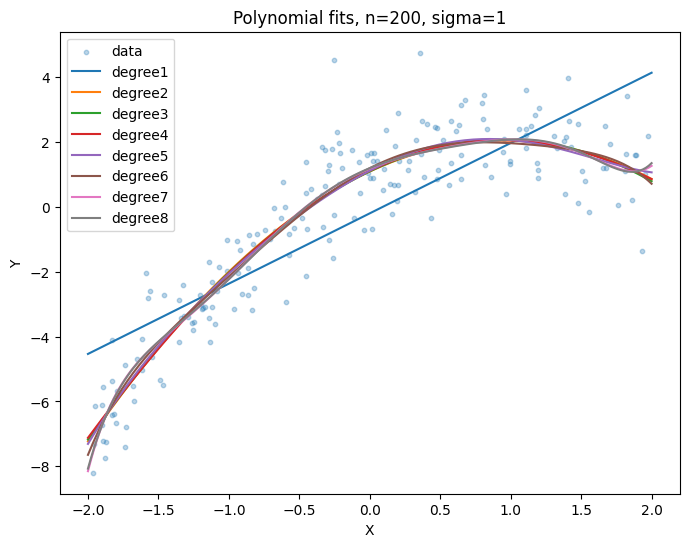

In [58]:
models = {}

for d in range(1, 9):
    poly = PolynomialFeatures(degree=d)
    Xd = poly.fit_transform(X.reshape(-1, 1))
    reg = LinearRegression().fit(Xd, Y)
    models[d] = (poly, reg)
    
x_grid = np.linspace(-2, 2, 200).reshape(-1, 1)

plt.figure(figsize=(8, 6))
plt.scatter(X, Y, s=10, alpha=0.3, label="data")

for d in range(1, 9):
    poly, reg = models[d]
    y_pred = reg.predict(poly.transform(x_grid))
    plt.plot(x_grid, y_pred, label = f"degree{d}")
    
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial fits, n=200, sigma=1")
plt.show()    


### b. Use 5-fold cross-validation to choose polynomial degree. 

In [59]:
# 5 fold 
kf = KFold(n_splits=5, shuffle=True, random_state=1)
cv_errors = {} # parse this

for d in range(1, 9):
    fold_mse = []
    for train_idx, val_idx, in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]
        
        poly = PolynomialFeatures(degree=d)
        Xd_train = poly.fit_transform(X_train.reshape(-1, 1))
        Xd_val = poly.transform(X_val.reshape(-1, 1))
        
        reg = LinearRegression().fit(Xd_train, Y_train)
        y_pred = reg.predict(Xd_val)
        fold_mse.append(np.mean((Y_val - y_pred)**2))
        
    cv_errors[d] = np.mean(fold_mse)
    
best_d = min(cv_errors, key=cv_errors.get)
print(cv_errors)
print(f"Best Degree: {best_d}")
        

{1: np.float64(2.7534719139966244), 2: np.float64(1.1027397002551387), 3: np.float64(1.1171461276631152), 4: np.float64(1.1281840783694996), 5: np.float64(1.1400776010516522), 6: np.float64(1.1385052511180125), 7: np.float64(1.1351498893253353), 8: np.float64(1.1531444283068875)}
Best Degree: 2


### c. Repeat the experiment for two noise levels: $\sigma = 0.5$ and $\sigma = 2$. 

In [60]:
def experiment(sigma, seed=2):
    np.random.seed(seed)
    X = np.random.uniform(-2, 2, n)
    eps = np.random.normal(0, sigma, n)
    Y = 1 + 2*X - X**2 + eps
    
    kf = KFold(n_splits=5, shuffle=True, random_state=1)
    cv_errors = {}
    for d in range(1, 9):
        fold_mse = []
        for train_idx, val_idx in kf.split(X):
            X_train, X_val = X[train_idx], X[val_idx]
            Y_train, Y_val = Y[train_idx], Y[val_idx]

            poly = PolynomialFeatures(degree=d)
            Xd_train = poly.fit_transform(X_train.reshape(-1, 1))
            Xd_val = poly.transform(X_val.reshape(-1, 1))

            reg = LinearRegression().fit(Xd_train, Y_train)
            y_pred = reg.predict(Xd_val)
            fold_mse.append(np.mean((Y_val - y_pred)**2))

        cv_errors[d] = np.mean(fold_mse)

    best_d = min(cv_errors, key=cv_errors.get)
    return X, Y, cv_errors, best_d


In [61]:
results = {}
for s in [0.5, 2.0]:
    X_s, Y_s, cv_errors_s, best_d_s = experiment(s)
    results[s] = {"X": X_s, "Y": Y_s, "cv_errors": cv_errors_s, "best_d": best_d_s}
    print(f"sigma={s}: best degree = {best_d_s}")
    print(f"cv_errors = {cv_errors_s}")


sigma=0.5: best degree = 2
cv_errors = {1: np.float64(1.8422133401519099), 2: np.float64(0.2756849250637847), 3: np.float64(0.2792865319157788), 4: np.float64(0.28204601959237496), 5: np.float64(0.28501940026291317), 6: np.float64(0.2846263127795027), 7: np.float64(0.28378747233133383), 8: np.float64(0.28828610707672225)}
sigma=2.0: best degree = 2
cv_errors = {1: np.float64(6.225563899266594), 2: np.float64(4.410958801020555), 3: np.float64(4.468584510652465), 4: np.float64(4.512736313477999), 5: np.float64(4.560310404206614), 6: np.float64(4.554021004472046), 7: np.float64(4.54059955730134), 8: np.float64(4.612577713227567)}


### Report the cross-validation errors in a table and plot the fitted curve for the selected model. 

sigma,0.5,1.0,2.0
degree,,,
1,1.8422,2.7535,6.2256
2,0.2757,1.1027,4.4110
3,0.2793,1.1171,4.4686
4,0.2820,1.1282,4.5127
5,0.2850,1.1401,4.5603
6,0.2846,1.1385,4.5540
7,0.2838,1.1351,4.5406
8,0.2883,1.1531,4.6126


Selected degree by 5-fold CV: {0.5: 2, 1.0: 2, 2.0: 2}


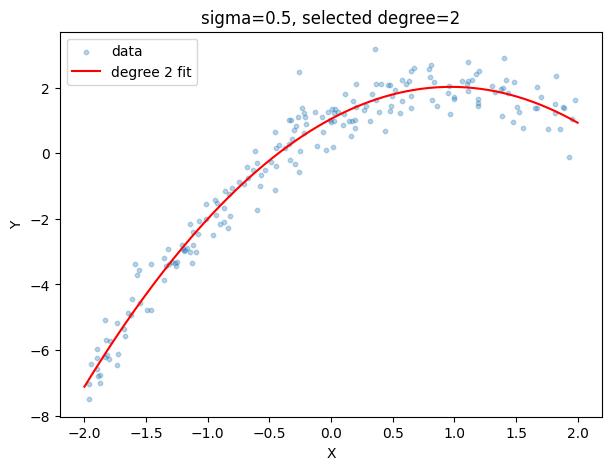

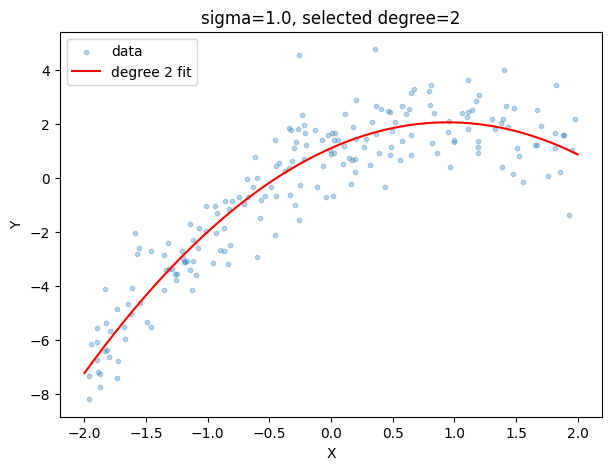

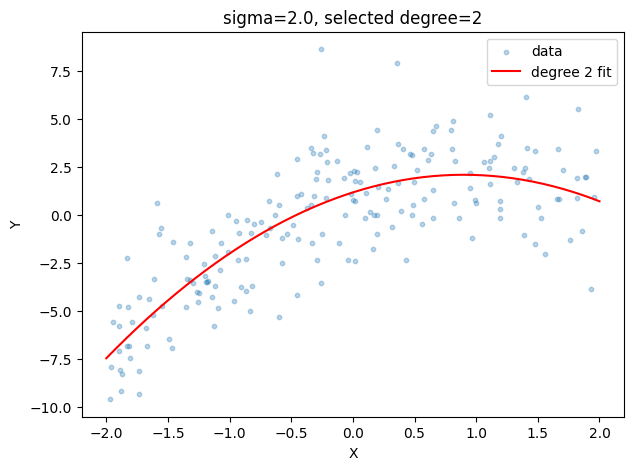

In [62]:
from IPython.display import display

# combine sigma=1 results (from part b) with sigma=0.5, 2.0 (from part c)
all_results = {
    0.5: results[0.5],
    1.0: {"X": X, "Y": Y, "cv_errors": cv_errors, "best_d": best_d},
    2.0: results[2.0],
}

# --- table of CV errors, degree x sigma ---
cv_table = pd.DataFrame({s: all_results[s]["cv_errors"] for s in sorted(all_results)})
cv_table.index.name = "degree"
cv_table.columns.name = "sigma"
display(cv_table.round(4))

best_degrees = {s: all_results[s]["best_d"] for s in sorted(all_results)}
print("Selected degree by 5-fold CV:", best_degrees)

# --- plot the fitted curve for the CV-selected model, one figure per sigma ---
x_grid = np.linspace(-2, 2, 200).reshape(-1, 1)

for s in sorted(all_results):
    Xs, Ys, best_d_s = all_results[s]["X"], all_results[s]["Y"], all_results[s]["best_d"]

    poly = PolynomialFeatures(degree=best_d_s)
    Xd = poly.fit_transform(Xs.reshape(-1, 1))
    reg = LinearRegression().fit(Xd, Ys)
    y_pred = reg.predict(poly.transform(x_grid))

    plt.figure(figsize=(7, 5))
    plt.scatter(Xs, Ys, s=10, alpha=0.3, label="data")
    plt.plot(x_grid, y_pred, color="red", label=f"degree {best_d_s} fit")
    plt.title(f"sigma={s}, selected degree={best_d_s}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()


### e. Discuss how the selected degree changes with the noise level.

5-fold CV selects **degree 2** (the true degree) at all three noise levels ($\sigma = 0.5, 1, 2$): degree 1 is always rejected by a wide margin, while degree 2 beats degree 3 by only ~1.3% at every $\sigma$, since the true cubic coefficient is 0 and adding it costs almost no bias. Because the true model lies inside the candidate class for every $d \ge 2$, there's no bias left to trade off against variance as $\sigma$ grows hence the selected degree stays fixed at 2 regardless of the noise level.


## Problem 5 (Prediction and Housing Prices)

Zillow is an online real estate database company that was founded in 2006. An important task for Zillow is to predict the house price. However, their accuracy has been criticized a lot. According to Fortune, ”Zillow has Zestimated the value of 57 percent of U.S. housing stock, but only 65 percent of that could be considered ‘accurate’ – by its definition, within 10 percent of the actual selling price. And even that accuracy isn’t equally distributed”. Therefore, Zillow needs your help to build a housing pricing model to improve their accuracy. Download the training and testing data and read the data (training data: 15129 cases, testing data: 6484 cases). Make sure that zip code is treated as factor. Letting $\tau$ as a test set, define out-of-sample $R^2$ as of a prediction method $\{ \hat{y}^{\text{method}}_i \}$ as

$$R^2 = 1 - \frac{\sum_{i \in \tau} (y_i - \hat{y}_i)^2}{\sum_{i \in \tau} (y_i - \bar{y}_{\text{train}})^2}$$

where $\bar{y}_{\text{train}} = \text{ave}(\{y_i\}_{i \in \tau_0})$ and $\tau_0$ is the training set.

### a. Calculate out-of-sample $R^2$ using variables "bathrooms", "bedrooms", "sqft_living", and "sqft_lot". 

In [63]:
train_data = pd.read_csv('train.data_.csv')
test_data = pd.read_csv('test.data_.csv')

train_data['zipcode'] = train_data['zipcode'].astype('category')
test_data['zipcode'] = test_data['zipcode'].astype('category')

print(train_data.head())
print(train_data.tail())
print(test_data.head())
print(test_data.tail())


   Unnamed: 0          id             date    price  bedrooms  bathrooms  \
0           2  6414100192  20141209T000000   538000         3       2.25   
1           4  2487200875  20141209T000000   604000         4       3.00   
2           5  1954400510  20150218T000000   510000         3       2.00   
3           6  7237550310  20140512T000000  1225000         4       4.50   
4           7  1321400060  20140627T000000   257500         3       2.25   

   sqft_living  sqft_lot  floors  waterfront  ...  grade  sqft_above  \
0         2570      7242     2.0           0  ...      7        2170   
1         1960      5000     1.0           0  ...      7        1050   
2         1680      8080     1.0           0  ...      8        1680   
3         5420    101930     1.0           0  ...     11        3890   
4         1715      6819     2.0           0  ...      7        1715   

   sqft_basement  yr_built  yr_renovated  zipcode      lat     long  \
0            400      1951          199

In [64]:
features_a = ["bathrooms", "bedrooms", "sqft_living", "sqft_lot"]

X_train_a = train_data[features_a]
y_train = train_data["price"]
X_test_a = test_data[features_a]
y_test = test_data["price"]

reg_a = LinearRegression().fit(X_train_a, y_train)
y_pred_a = reg_a.predict(X_test_a)

y_train_mean = y_train.mean()
r2_oos_a = 1 - np.sum((y_test - y_pred_a)**2) / np.sum((y_test - y_train_mean)**2)

print(f"Out-of-sample R^2 (a): {r2_oos_a:.4f}")


Out-of-sample R^2 (a): 0.5051


### b. Calculate out-of-sample $R^2$ using the 4 variables above along with interaction terms. 

In [65]:
poly_b = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

X_train_b = poly_b.fit_transform(train_data[features_a])
X_test_b = poly_b.transform(test_data[features_a])

# standardize: sqft_living*sqft_lot reaches ~5.7e9, which ill-conditions the raw fit
reg_b = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train_b, y_train)
y_pred_b = reg_b.predict(X_test_b)

r2_oos_b = 1 - np.sum((y_test - y_pred_b)**2) / np.sum((y_test - y_train_mean)**2)

print(f"Out-of-sample R^2 (b): {r2_oos_b:.4f}")


Out-of-sample R^2 (b): 0.5329


### c. Add the factor zipcode to (b) and compute out-of-sample $R^2$. 

In [66]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
zip_train = ohe.fit_transform(train_data[['zipcode']])
zip_test = ohe.transform(test_data[['zipcode']])

X_train_c = np.hstack([X_train_b, zip_train])
X_test_c = np.hstack([X_test_b, zip_test])

reg_c = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train_c, y_train)
y_pred_c = reg_c.predict(X_test_c)

r2_oos_c = 1 - np.sum((y_test - y_pred_c)**2) / np.sum((y_test - y_train_mean)**2)

print(f"Out-of-sample R^2 (c): {r2_oos_c:.4f}")


Out-of-sample R^2 (c): 0.7620


### d. Add the following additional variables to (d) (below) and compute out-of-sample $R^2$.


$$X_{12} = I(\text{view} = 0)$$

$$X_{13} = L^2$$

$$X_{13+i} = (L - \tau_i)_+^2, \quad i = 1, \ldots, 9$$

where $\tau_i$ is the $10 \times i$-th percentile and $L$ is the size of living area ("sqft living").



In [67]:
L_train = train_data["sqft_living"]
L_test = test_data["sqft_living"]
taus = np.percentile(L_train, [10 * i for i in range(1, 10)])

view0_train = (train_data["view"] == 0).astype(int).to_numpy().reshape(-1, 1)
view0_test = (test_data["view"] == 0).astype(int).to_numpy().reshape(-1, 1)

L2_train = (L_train ** 2).to_numpy().reshape(-1, 1)
L2_test = (L_test ** 2).to_numpy().reshape(-1, 1)

spline_train = np.column_stack([np.maximum(L_train - tau, 0) ** 2 for tau in taus])
spline_test = np.column_stack([np.maximum(L_test - tau, 0) ** 2 for tau in taus])

X_train_d = np.hstack([X_train_c, view0_train, L2_train, spline_train])
X_test_d = np.hstack([X_test_c, view0_test, L2_test, spline_test])

reg_d = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train_d, y_train)
y_pred_d = reg_d.predict(X_test_d)

r2_oos_d = 1 - np.sum((y_test - y_pred_d)**2) / np.sum((y_test - y_train_mean)**2)

print(f"Out-of-sample R^2 (d): {r2_oos_d:.4f}")


Out-of-sample R^2 (d): 0.7805


### e. Now without assessing to the test data, using the 5-fold cross-validation and the training data alone, compute the out-of-sample $R^2$ for the last model. 

In [68]:
def build_design(sub_train, sub_val):
    Xb_tr = poly_b.transform(sub_train[features_a])
    Xb_va = poly_b.transform(sub_val[features_a])

    ohe_cv = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    zip_tr = ohe_cv.fit_transform(sub_train[['zipcode']])
    zip_va = ohe_cv.transform(sub_val[['zipcode']])

    L_tr, L_va = sub_train['sqft_living'], sub_val['sqft_living']
    taus_cv = np.percentile(L_tr, [10 * i for i in range(1, 10)])

    view_tr = (sub_train['view'] == 0).astype(int).to_numpy().reshape(-1, 1)
    view_va = (sub_val['view'] == 0).astype(int).to_numpy().reshape(-1, 1)

    L2_tr = (L_tr ** 2).to_numpy().reshape(-1, 1)
    L2_va = (L_va ** 2).to_numpy().reshape(-1, 1)

    spline_tr = np.column_stack([np.maximum(L_tr - t, 0) ** 2 for t in taus_cv])
    spline_va = np.column_stack([np.maximum(L_va - t, 0) ** 2 for t in taus_cv])

    X_tr = np.hstack([Xb_tr, zip_tr, view_tr, L2_tr, spline_tr])
    X_va = np.hstack([Xb_va, zip_va, view_va, L2_va, spline_va])
    return X_tr, X_va

kf = KFold(n_splits=5, shuffle=True, random_state=1)
sse_total, sst_total = 0.0, 0.0

for tr_idx, va_idx in kf.split(train_data):
    sub_train, sub_val = train_data.iloc[tr_idx], train_data.iloc[va_idx]
    y_tr, y_va = sub_train['price'], sub_val['price']

    X_tr, X_va = build_design(sub_train, sub_val)
    model = make_pipeline(StandardScaler(), LinearRegression()).fit(X_tr, y_tr)
    y_pred_va = model.predict(X_va)

    sse_total += np.sum((y_va - y_pred_va) ** 2)
    sst_total += np.sum((y_va - y_tr.mean()) ** 2)

r2_cv_e = 1 - sse_total / sst_total
print(f"5-fold CV out-of-sample R^2 (e): {r2_cv_e:.4f}")


5-fold CV out-of-sample R^2 (e): 0.7810


In [69]:
summary_5 = pd.DataFrame({
    "model": [
        "(a) bathrooms, bedrooms, sqft_living, sqft_lot",
        "(b) + pairwise interactions",
        "(c) + zipcode factor",
        "(d) + I(view=0), L^2, 9 spline terms",
        "(e) model (d), 5-fold CV on training data alone",
    ],
    "R^2_out": [r2_oos_a, r2_oos_b, r2_oos_c, r2_oos_d, r2_cv_e],
})
summary_5["R^2_out"] = summary_5["R^2_out"].round(4)
summary_5


,model,R^2_out
0,"(a) bathrooms, bedrooms, sqft_living, sqft_lot",0.5051
1,(b) + pairwise interactions,0.5329
2,(c) + zipcode factor,0.7620
3,"(d) + I(view=0), L^2, 9 spline terms",0.7805
4,"(e) model (d), 5-fold CV on training data alone",0.7810


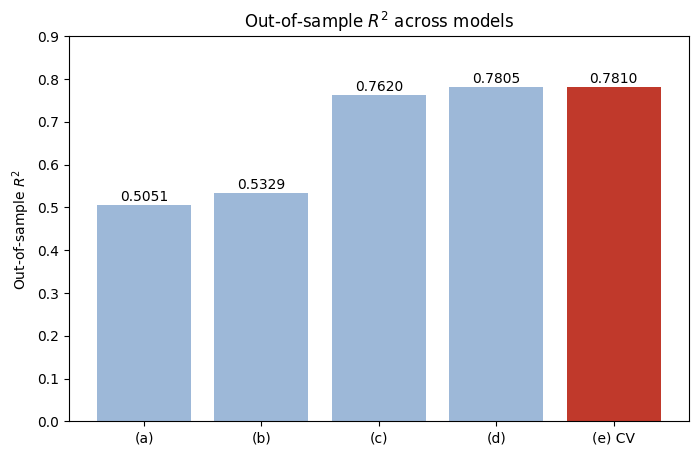

In [71]:
plt.figure(figsize=(8, 5))
bars = plt.bar(["(a)", "(b)", "(c)", "(d)", "(e) CV"], summary_5["R^2_out"],
                color=["#9db8d8", "#9db8d8", "#9db8d8", "#9db8d8", "#c0392b"])
for bar, val in zip(bars, summary_5["R^2_out"]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.4f}", ha="center")

plt.ylabel("Out-of-sample $R^2$")
plt.title("Out-of-sample $R^2$ across models")
plt.ylim(0, 0.9)
plt.show()
